# Final presentation figures


## Setup


In [221]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "monospace"
# TrueType (Type 42) so PDF text stays editable vectors instead of raster outlines.
plt.rcParams["pdf.fonttype"] = 42


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for path in (here, *here.parents):
        if (path / "window_sequence_analysis").is_dir():
            return path
    raise FileNotFoundError("Could not locate the repository root.")


def resolve_data_dir(root: Path, data_dir: str) -> Path:
    path = Path(data_dir)
    resolved = path if path.is_absolute() else (root / path)
    resolved = resolved.resolve()
    if not resolved.is_dir():
        raise FileNotFoundError(f"Data directory not found: {resolved}")
    return resolved


def latest_profile_csv(data_dir: Path) -> Path:
    filename = "window_sequence_profiles.csv"
    results_root = data_dir / "results"
    run_profiles = list((results_root / "runs").glob(f"*/{filename}"))
    if run_profiles:
        return max(run_profiles, key=lambda path: path.stat().st_mtime_ns)
    legacy_profile = results_root / filename
    if legacy_profile.is_file():
        return legacy_profile
    raise FileNotFoundError(
        f"No {filename} found in {results_root / 'runs'} or {results_root}."
    )


ROOT = repo_root_from_here()
DATA_DIR = "data/skin_samples"
DATA_PATH = resolve_data_dir(ROOT, DATA_DIR)
PROFILES_CSV = latest_profile_csv(DATA_PATH)
TISSUE_TSV = DATA_PATH / "ms_tissue.tsv"

CLUSTER_COL = "single_cell_expression_cluster"
GENE_NAME_COL = "GN"
UNASSIGNED_LABEL = "(unassigned)"

print("ROOT:", ROOT)
print("profiles:", PROFILES_CSV)
print("tissue table:", TISSUE_TSV)


ROOT: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction
profiles: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/runs/2026-09-16_20-47/window_sequence_profiles.csv
tissue table: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/ms_tissue.tsv


## Load and sort by cluster

Profiles are grouped on `single_cell_expression_cluster`. Unassigned proteins are left out, and the table is ordered by cluster number.


In [222]:
def cluster_label(value: object) -> str:
    text = "" if pd.isna(value) else str(value).strip()
    return text or UNASSIGNED_LABEL


def cluster_sort_key(name: str) -> tuple[int, int, str]:
    match = re.match(r"Cluster\s+(\d+)", name)
    if match:
        return (0, int(match.group(1)), name)
    if name == UNASSIGNED_LABEL:
        return (2, 0, name)
    return (1, 0, name)


def load_cluster_table(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Window profile CSV not found: {path}")
    frame = pd.read_csv(path)
    required = {CLUSTER_COL, GENE_NAME_COL}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Profile CSV missing columns: {missing}")
    if frame.empty:
        raise ValueError(f"Window profile CSV is empty: {path}")
    labels = frame[CLUSTER_COL].map(cluster_label)
    kept = frame.loc[labels != UNASSIGNED_LABEL].copy()
    kept[CLUSTER_COL] = labels.loc[kept.index].to_numpy()
    kept["_cluster_key"] = kept[CLUSTER_COL].map(cluster_sort_key)
    ordered = kept.sort_values("_cluster_key", kind="mergesort").drop(columns="_cluster_key")
    return ordered.reset_index(drop=True)


profiles = load_cluster_table(PROFILES_CSV)
print(f"Loaded {len(profiles):,} proteins in {profiles[CLUSTER_COL].nunique():,} clusters")


Loaded 4,601 proteins in 110 clusters


## Skin intensity

`Gene name` in `ms_tissue.tsv` is matched to `GN`. Only Tissue `skin` is used. A blank skin intensity is stored as 0, and a gene missing from the skin table is left as missing.


In [223]:
def _skin_intensity_value(intensity: object) -> float:
    value = pd.to_numeric(intensity, errors="coerce")
    if pd.isna(value):
        return 0.0
    return float(value)


def load_skin_intensity(path: Path) -> dict[str, float]:
    if not path.is_file():
        raise FileNotFoundError(f"Tissue table not found: {path}")
    frame = pd.read_csv(path, sep="\t", usecols=["Gene name", "Tissue", "Intensity"])
    skin = frame.loc[frame["Tissue"].astype(str).str.strip().str.casefold() == "skin"]
    scores: dict[str, float] = {}
    for gene_name, intensity in zip(skin["Gene name"], skin["Intensity"], strict=True):
        name = "" if pd.isna(gene_name) else str(gene_name).strip()
        if not name:
            continue
        value = _skin_intensity_value(intensity)
        previous = scores.get(name)
        if previous is None:
            scores[name] = value
            continue
        both_present = np.isfinite(previous) and np.isfinite(value)
        if both_present and previous != value:
            raise ValueError(f"{name} has conflicting skin intensities: {previous} and {value}.")
        if not np.isfinite(previous) and np.isfinite(value):
            scores[name] = value
    return scores


def append_skin_intensity(frame: pd.DataFrame, scores: dict[str, float]) -> pd.DataFrame:
    out = frame.copy()
    genes = out[GENE_NAME_COL].map(lambda value: "" if pd.isna(value) else str(value).strip())
    out["skin_intensity"] = genes.map(scores)
    return out


skin_intensity_by_gene = load_skin_intensity(TISSUE_TSV)
profiles = append_skin_intensity(profiles, skin_intensity_by_gene)
matched = int(profiles["skin_intensity"].notna().sum())
print(f"Skin genes in tissue table: {len(skin_intensity_by_gene):,}")
print(f"Proteins with a skin intensity: {matched:,}")
print(f"Proteins missing from the skin table: {len(profiles) - matched:,}")


Skin genes in tissue table: 19,295
Proteins with a skin intensity: 4,568
Proteins missing from the skin table: 33


## Cluster size


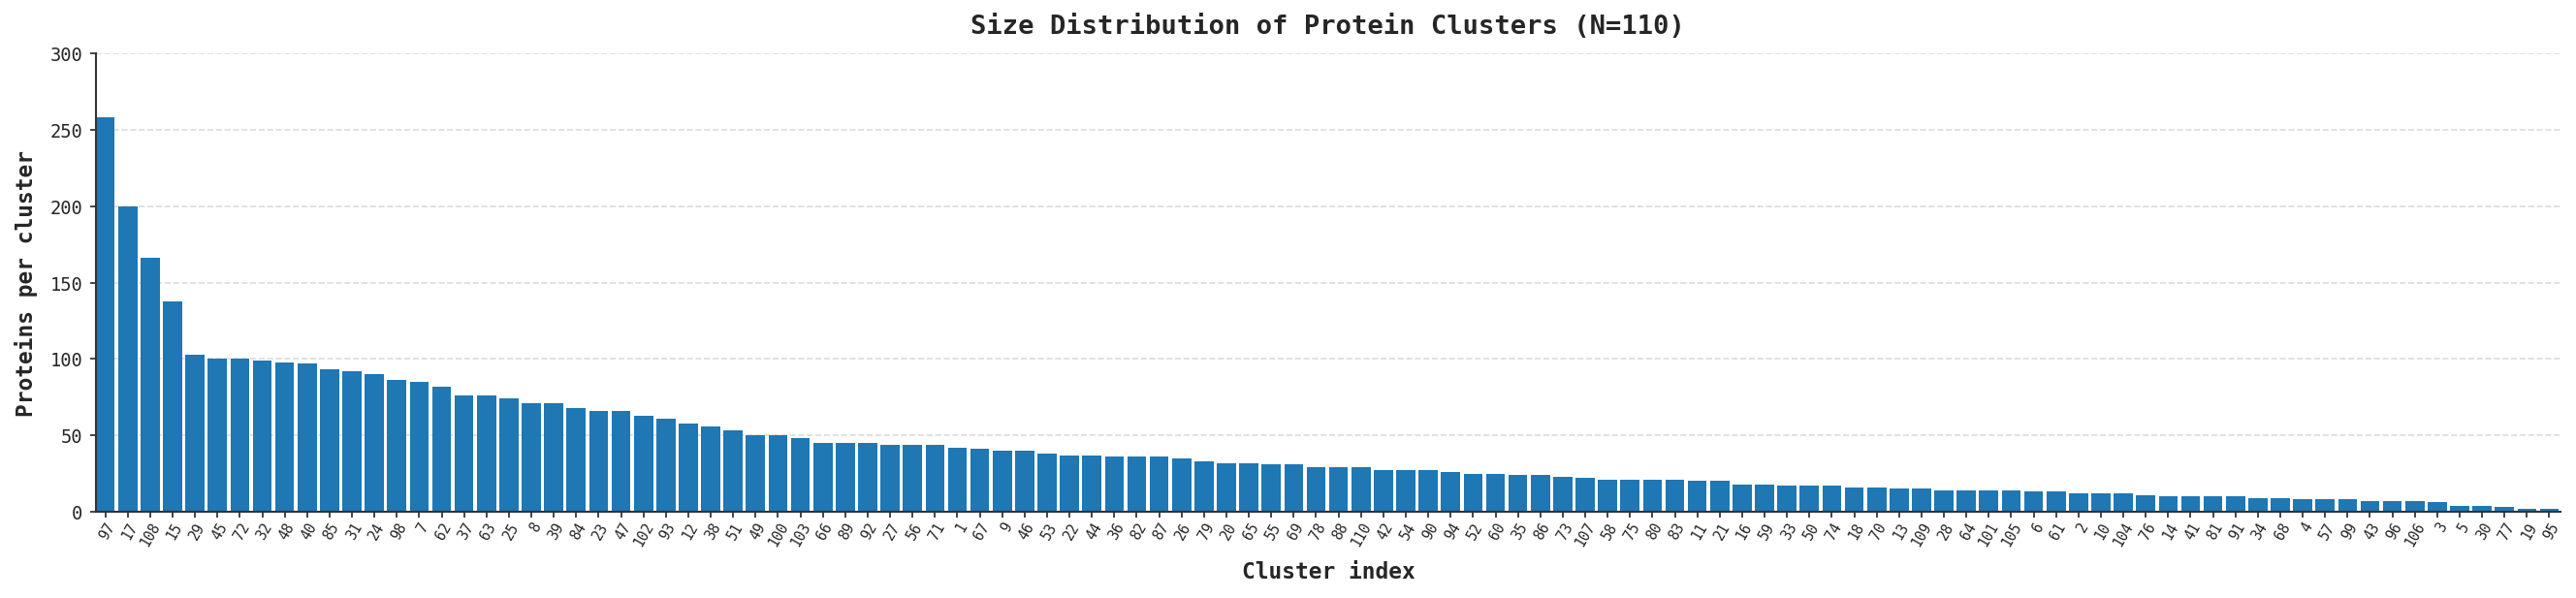

In [224]:
def cluster_number_label(name: str) -> str:
    match = re.match(r"Cluster\s+(\d+)", name)
    return match.group(1) if match else name


def cluster_size_table(frame: pd.DataFrame) -> pd.DataFrame:
    counts = frame.groupby(CLUSTER_COL, sort=False).size().rename("protein_count")
    table = counts.reset_index()
    return table.sort_values("protein_count", ascending=False, kind="mergesort")


def plot_cluster_size_counts(table: pd.DataFrame, *, title: str | None = None) -> None:
    labels = [cluster_number_label(name) for name in table[CLUSTER_COL]]
    values = table["protein_count"].to_numpy()
    n = len(table)
    x = np.arange(n)

    bar_width = 0.85
    half_gap = (1.0 - bar_width) / 2.0

    fig_width = max(10.0, 0.16 * n)
    fig_height = 4.0

    fig, ax = plt.subplots(
        figsize=(fig_width, fig_height),
        dpi=150,
        layout="constrained",
    )

    ax.bar(x, values, width=bar_width, color="#1f77b4", edgecolor="none")

    # Clean axes spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")

    # Add horizontal grid lines only
    ax.grid(False)
    ax.grid(axis="y", linestyle="--", alpha=0.7, zorder=0)
    ax.set_axisbelow(True)

    # Set left border gap to match space between bars
    ax.set_xlim(-0.5 + half_gap, n - 0.5)

    # Overhead padding fix so highest bar has breathing room
    max_val = max(values) if len(values) > 0 else 50
    ax.set_ylim(0, max_val * 1.05)

    # Labels and title
    ax.set_xlabel("Cluster index", fontsize=11, fontweight="bold", labelpad=6)
    ax.set_ylabel("Proteins per cluster", fontsize=11, fontweight="bold", labelpad=6)
    if title is None:
        title = f"Size Distribution of Protein Clusters (N={n})"
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    # Count Y-axis ticks in increments of 50
    ax.set_yticks(np.arange(0, max_val + 50, 50))

    # Rotated X-tick labels and explicit Y-tick mark visibility
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right", rotation_mode="anchor", fontsize=7)
    ax.tick_params(axis="x", which="both", length=3, pad=1)
    ax.tick_params(axis="y", which="both", left=True, length=3, labelsize=9)

    plt.show()


cluster_sizes = cluster_size_table(profiles)
plot_cluster_size_counts(cluster_sizes)

## Cluster size by weighted DNGC rank

Same protein counts as the size chart. Clusters are ordered by `weighted_dngc`: the skin-intensity-weighted mean DNGC. Proteins with DNGC below 0.01, and proteins without a skin intensity, are left out of the weight. Clusters with no usable intensity are placed last.


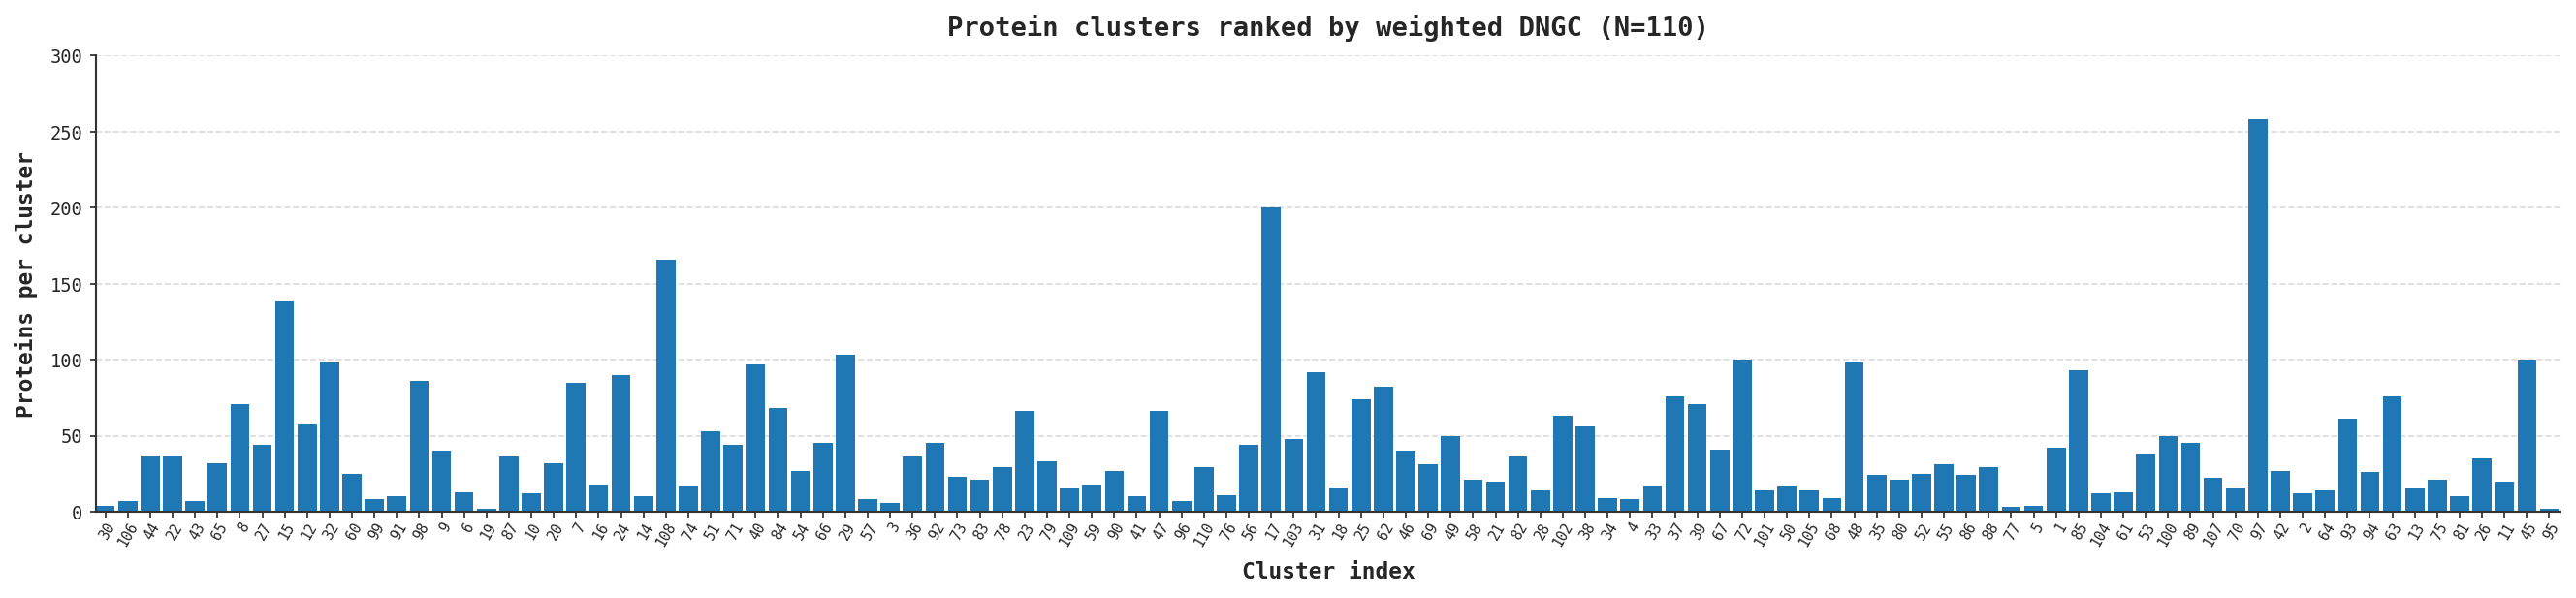

In [225]:
SIGMA_COLUMN = "hyperplane_distance_mean_profile"
DELIMITER_COL = "profile_delimiter"
SIGMA_ACTIVITY_THRESHOLD = 0.0
DNGC_MIN_THRESHOLD = 0.01


def parse_profile(text: object, delimiter: str = ";") -> np.ndarray:
    parts = str(text).split(delimiter or ";")
    values = np.empty(len(parts), dtype=np.float64)
    for index, part in enumerate(parts):
        token = part.strip()
        values[index] = np.nan if not token or token.lower() == "nan" else float(token)
    return values


def protein_dngc(text: object, delimiter: str) -> float:
    sigma = parse_profile(text, delimiter)
    active = np.isfinite(sigma) & (sigma > SIGMA_ACTIVITY_THRESHOLD)
    s_score = int(np.count_nonzero(active))
    if s_score == 0:
        return 0.0
    excess = sigma[active] - SIGMA_ACTIVITY_THRESHOLD
    return float(np.sum(excess) / s_score)


def cluster_sizes_by_weighted_dngc(frame: pd.DataFrame) -> pd.DataFrame:
    delimiters = frame[DELIMITER_COL].fillna(";").astype(str)
    dngc = np.fromiter(
        (
            protein_dngc(text, delimiter)
            for text, delimiter in zip(frame[SIGMA_COLUMN], delimiters, strict=True)
        ),
        dtype=np.float64,
        count=len(frame),
    )
    intensity = pd.to_numeric(frame["skin_intensity"], errors="coerce").to_numpy(dtype=np.float64)
    usable = np.isfinite(intensity) & (dngc >= DNGC_MIN_THRESHOLD)
    weights = np.where(usable, intensity, 0.0)
    work = pd.DataFrame(
        {
            CLUSTER_COL: frame[CLUSTER_COL].to_numpy(),
            "weight": weights,
            "weighted_part": np.where(usable, dngc * intensity, 0.0),
        }
    )
    grouped = work.groupby(CLUSTER_COL, sort=False)
    counts = grouped.size()
    total_weight = grouped["weight"].sum()
    score = grouped["weighted_part"].sum() / total_weight.replace(0, np.nan)
    table = pd.DataFrame(
        {
            CLUSTER_COL: counts.index,
            "protein_count": counts.to_numpy(),
            "weighted_dngc": score.reindex(counts.index).to_numpy(),
        }
    )
    table["_missing"] = ~np.isfinite(table["weighted_dngc"])
    table["_score"] = table["weighted_dngc"].fillna(0.0)
    table["_cluster_order"] = [
        cluster_sort_key(name)[1] if cluster_sort_key(name)[0] == 0 else 10**9
        for name in table[CLUSTER_COL]
    ]
    ordered = table.sort_values(
        ["_missing", "_score", "_cluster_order", CLUSTER_COL],
        ascending=[True, False, True, True],
        kind="mergesort",
    )
    return ordered.drop(columns=["_missing", "_score", "_cluster_order"]).reset_index(drop=True)


weighted_cluster_sizes = cluster_sizes_by_weighted_dngc(profiles)
plot_cluster_size_counts(
    weighted_cluster_sizes,
    title=f"Protein clusters ranked by weighted DNGC (N={len(weighted_cluster_sizes)})",
)


## Top 10 by weighted DNGC

Skin-intensity share by DNGC for the top 10 clusters, in a 2×5 grid. Proteins with DNGC below 0.01 are left out of the histogram. Under each title, the protein count after that filter and the cluster’s weighted DNGC, truncated to two decimals, are shown in regular weight.


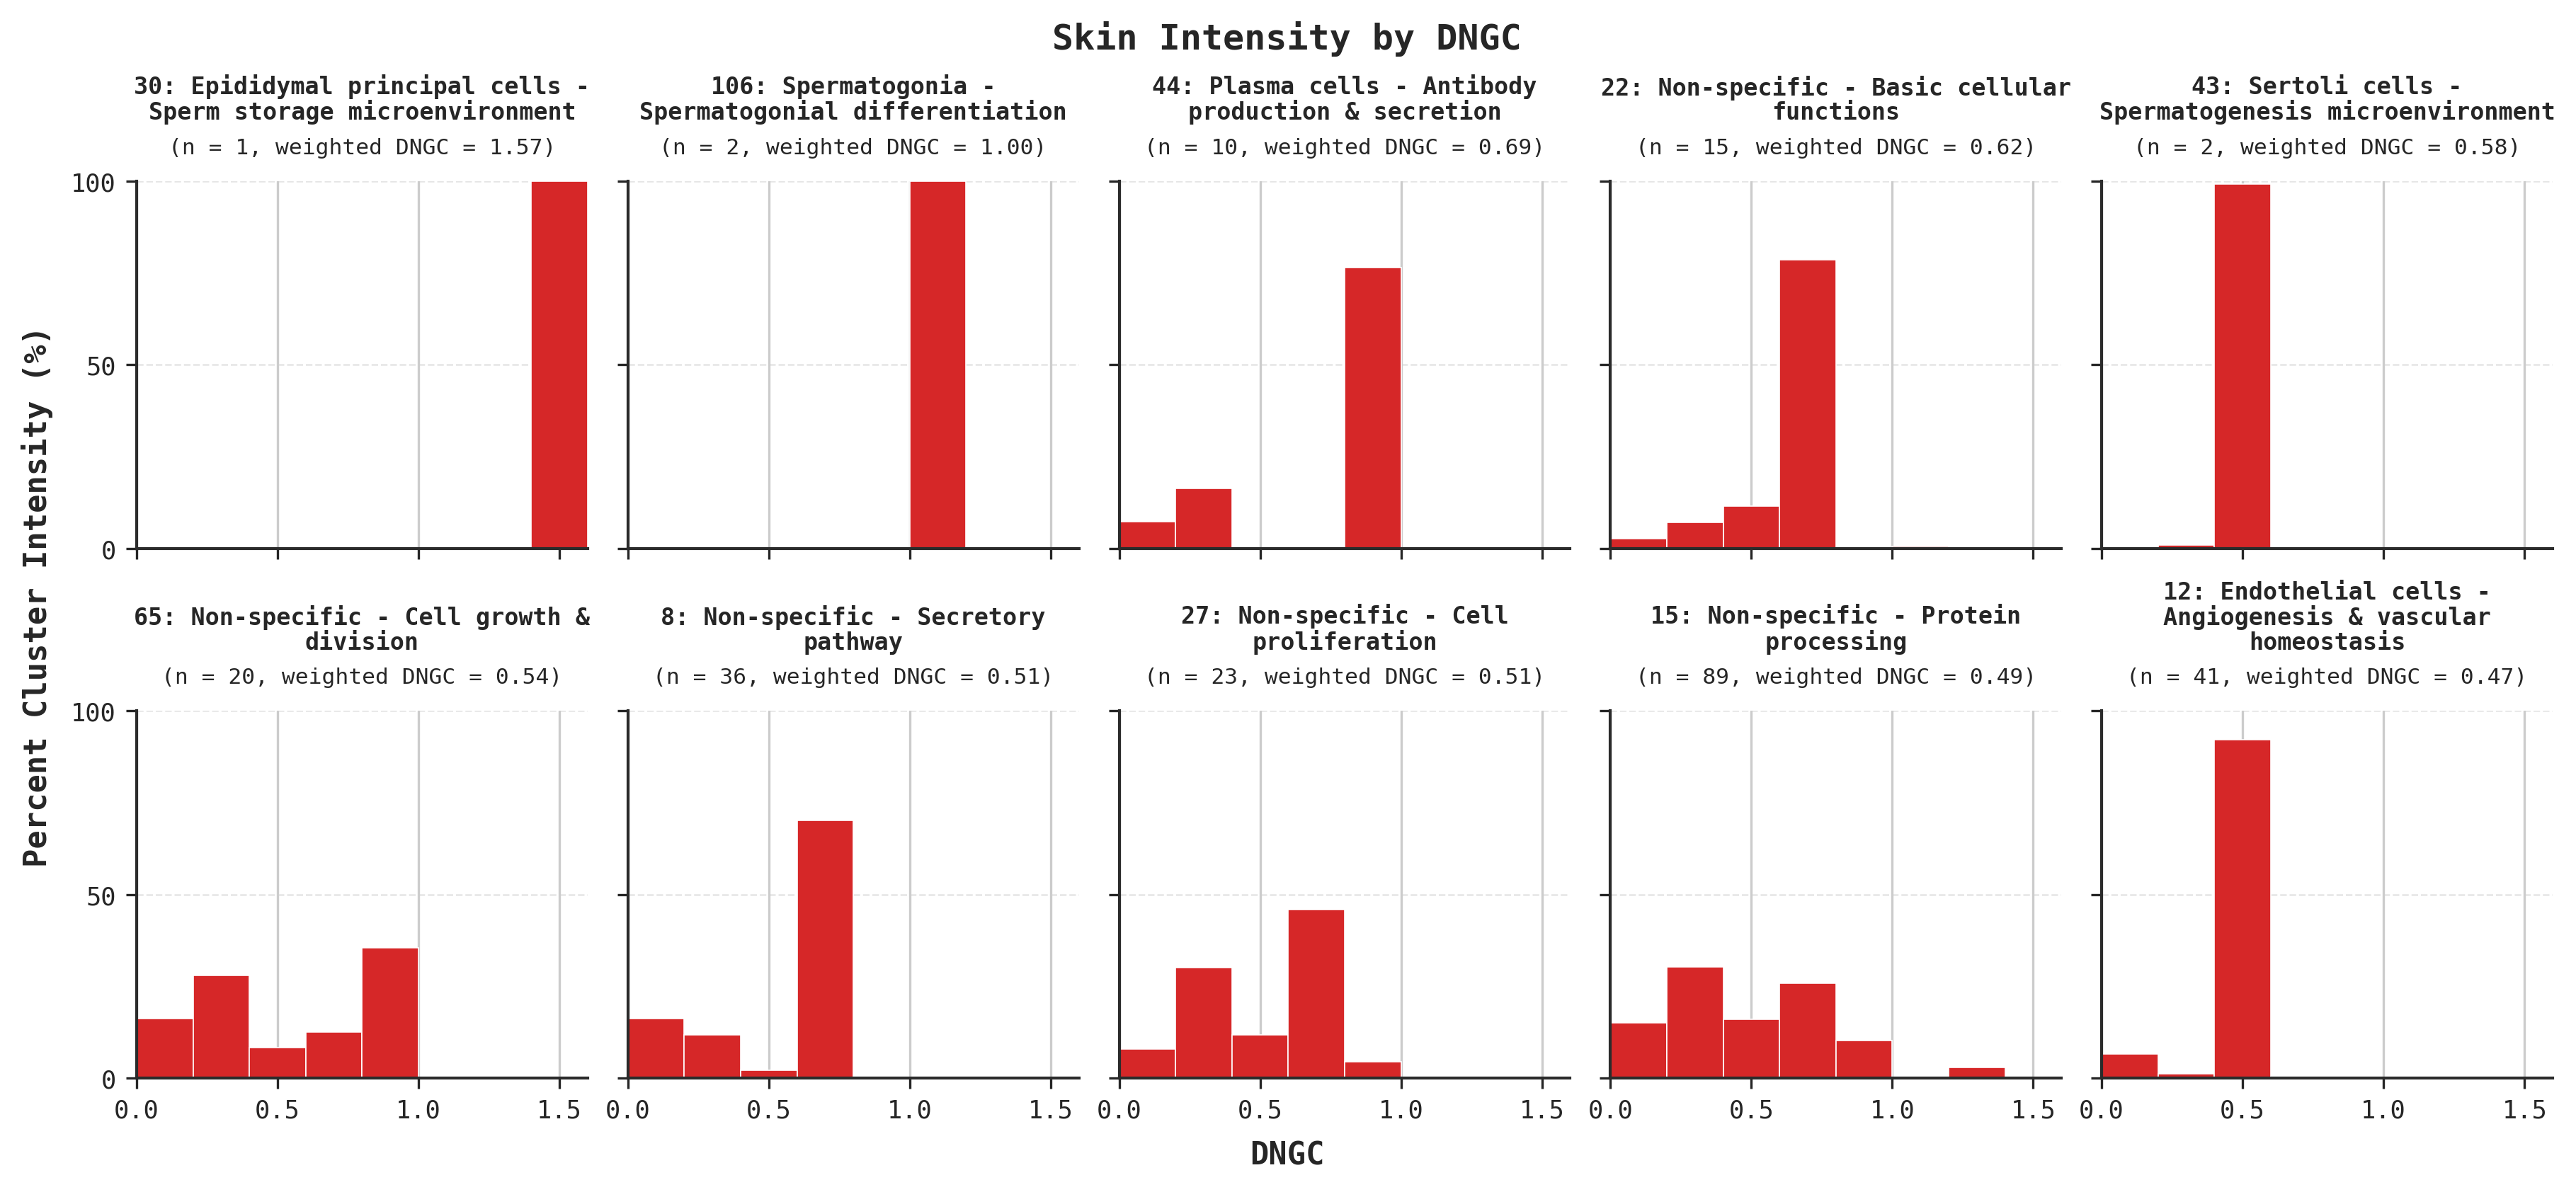

In [226]:
import textwrap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Constants & Configuration
N_ROWS, N_COLS = 2, 5
PANEL_COLOR = "#d62728"
SPINE_COLOR = "#2b2b2b"


def clean_cluster_title(name: str, width: int) -> str:
    cleaned = name.removeprefix("Cluster ")
    return "\n".join(textwrap.wrap(cleaned, width=width)) or cleaned


def characters_across(ax, fontsize: float) -> int:
    width_px = ax.get_window_extent().width
    char_px = 0.6 * fontsize * ax.figure.dpi / 72.0
    return max(16, int(width_px / max(char_px, 1.0)))


def calculate_histogram_bins(values: np.ndarray, target_bins: int = 8) -> np.ndarray:
    finite = values[np.isfinite(values)]
    vmax = float(finite.max()) if finite.size else 1.0

    raw_step = max(vmax / max(target_bins, 1), 1e-6)
    exp = np.floor(np.log10(raw_step))
    frac = raw_step / (10**exp)
    nice_mult = 1.0 if frac <= 1 else (2.0 if frac <= 2 else (5.0 if frac <= 5 else 10.0))
    step = nice_mult * (10**exp)

    upper = float(np.ceil(vmax / step) * step)
    return np.arange(0.0, upper + step, step)


def prepare_cluster_data(frame: pd.DataFrame, names: list[str]) -> list[pd.DataFrame]:
    delims = frame[DELIMITER_COL].fillna(";").astype(str)
    dngc = np.fromiter(
        (protein_dngc(t, d) for t, d in zip(frame[SIGMA_COLUMN], delims, strict=True)),
        dtype=np.float64,
        count=len(frame),
    )
    work = pd.DataFrame({
        CLUSTER_COL: frame[CLUSTER_COL],
        "dngc": dngc,
        "intensity": pd.to_numeric(frame["skin_intensity"], errors="coerce"),
    })

    filtered = work.loc[work["dngc"] >= DNGC_MIN_THRESHOLD]
    grouped = {name: grp for name, grp in filtered.groupby(CLUSTER_COL, sort=False)}
    return [grouped.get(name, pd.DataFrame(columns=work.columns)) for name in names]


def truncated_decimals(value: float, places: int = 2) -> str:
    if not np.isfinite(value):
        return "NA"
    factor = 10 ** places
    truncated = np.trunc(value * factor) / factor
    return f"{truncated:.{places}f}"


def panel_stats(count: int, weighted_dngc: float) -> str:
    score = truncated_decimals(weighted_dngc)
    return f"(n = {count}, weighted DNGC = {score})"


def plot_top_dngc_histograms(
    names: list[str],
    groups: list[pd.DataFrame],
    scores: list[float],
) -> None:
    all_dngc = np.concatenate([
        grp["dngc"].to_numpy(dtype=np.float64) for grp in groups if not grp.empty
    ]) if groups else np.empty(0, dtype=np.float64)
    bins = calculate_histogram_bins(all_dngc)

    fig, axes = plt.subplots(
        N_ROWS,
        N_COLS,
        figsize=(12.0, 5.5),
        dpi=300,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    ax_list = np.atleast_1d(axes).ravel()

    for ax, grp in zip(ax_list, groups):
        # Spines and grid styling
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color(SPINE_COLOR)
        ax.spines["bottom"].set_color(SPINE_COLOR)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5, zorder=0)
        ax.tick_params(labelsize=8.5, length=3.5, width=0.8)

        # Plot distribution
        valid = grp.dropna(subset=["intensity", "dngc"])
        tot = valid["intensity"].sum()
        if not valid.empty and tot > 0:
            weights = (valid["intensity"].to_numpy() / tot) * 100.0
            ax.hist(
                valid["dngc"],
                bins=bins,
                weights=weights,
                color=PANEL_COLOR,
                edgecolor="white",
                linewidth=0.4,
            )
        else:
            ax.text(0.5, 0.5, "No signal", ha="center", va="center", transform=ax.transAxes, fontsize=8.5, color="#666666")

    # Title wrapping
    fig.canvas.draw()
    title_size = 8
    for ax, name, grp, score in zip(ax_list, names, groups, scores):
        ax.set_title(
            clean_cluster_title(name, characters_across(ax, title_size)),
            fontsize=title_size,
            fontweight="bold",
            linespacing=1.05,
            pad=21,
        )
        ax.annotate(
            panel_stats(len(grp), score),
            xy=(0.5, 1.0),
            xycoords="axes fraction",
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.5,
            fontfamily="monospace",
            fontweight="normal",
            annotation_clip=False,
        )

    # Restrict y-axis back to exactly [0, 100]
    ax_list[0].set_ylim(0.0, 100.0)
    ax_list[0].set_yticks([0, 50, 100])

    # X-axis ticks
    ax_list[0].set_xlim(float(bins[0]), float(bins[-1]))
    histogram_end = float(bins[-1])
    histogram_ticks = 0.5 * np.arange(int(np.floor(histogram_end / 0.5 + 1e-9)) + 1)
    ax_list[0].set_xticks(histogram_ticks)

    for ax in ax_list[len(names):]:
        ax.set_visible(False)

    fig.suptitle("Skin Intensity by DNGC", fontsize=12, fontweight="bold")
    fig.supxlabel("DNGC", fontsize=10.5, fontweight="bold")
    fig.supylabel("Percent Cluster Intensity (%)", fontsize=10.5, fontweight="bold")
    plt.show()


# Execution
top_names = weighted_cluster_sizes[CLUSTER_COL].head(N_ROWS * N_COLS).tolist()
top_groups = prepare_cluster_data(profiles, top_names)
score_by_name = weighted_cluster_sizes.set_index(CLUSTER_COL)["weighted_dngc"]
top_scores = [float(score_by_name.get(name, np.nan)) for name in top_names]
plot_top_dngc_histograms(top_names, top_groups, top_scores)